In [2]:
# -----------------------------------------------------------------------------
# Bootstrap (added by patch v2): Colab + Google Drive aware
# -----------------------------------------------------------------------------
import os, sys, subprocess, pathlib

IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB:
    try:
        import google.colab  # noqa: F401
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/EarningsLens")
    # The unpacked codebase (movingtargetLM/src/) should sit alongside the
    # notebooks under MyDrive/EarningsLens/. Adjust if your layout differs.
    CODEBASE_ROOT = PROJECT_ROOT
else:
    # Local fallback: assume the workspace layout produced by patch_v2.
    PROJECT_ROOT  = pathlib.Path(os.environ.get(
        "EARNINGSLENS_ROOT",
        "/home/user/workspace/earningslens_real",
    ))
    CODEBASE_ROOT = PROJECT_ROOT

DATA_DIR      = PROJECT_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"
for d in (RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.append('/content/drive/MyDrive/EarningsLens/src')

# Make `from src.<...> import ...` work
if str(CODEBASE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODEBASE_ROOT))

# Install the runtime deps actually used by NB02..NB08 (idempotent).
_REQUIRED = [
    "polars", "duckdb", "pyarrow", "pandas", "numpy", "matplotlib",
    "seaborn", "scipy", "spacy", "tiktoken", "httpx", "sentence-transformers",
    "chromadb", "tenacity", "tqdm",
]
def _ensure_packages():
    missing = []
    for pkg in _REQUIRED:
        mod = pkg.replace("-", "_")
        try:
            __import__(mod)
        except Exception:
            missing.append(pkg)
    if missing:
        print(f"Installing: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure_packages()


print(f"Bootstrap OK | IN_COLAB={IN_COLAB}")
print(f"  PROJECT_ROOT  = {PROJECT_ROOT}")
print(f"  CODEBASE_ROOT = {CODEBASE_ROOT}")
print(f"  RAW_DIR       = {RAW_DIR}")
print(f"  PROCESSED_DIR = {PROCESSED_DIR}")

Mounted at /content/drive
Installing: ['chromadb']
Bootstrap OK | IN_COLAB=True
  PROJECT_ROOT  = /content/drive/MyDrive/EarningsLens
  CODEBASE_ROOT = /content/drive/MyDrive/EarningsLens
  RAW_DIR       = /content/drive/MyDrive/EarningsLens/data/raw
  PROCESSED_DIR = /content/drive/MyDrive/EarningsLens/data/processed


# 08 — Demo Preparation & Pre-computation

## Architecture Overview

```
  This notebook (offline)           Live demo (online)
  ─────────────────────────         ──────────────────────────────
  transcripts → LLM extraction  →   load cache → Reporter Agent
               → spaCy baseline →   ↑                    ↓
               → semantic MT    →   Gradio UI ← narrative
               → pipeline run   ↗
  cache to JSON/disk ─────────────────────────────────────────────
```

**Why pre-compute?**
- Eliminates API latency risk during the live presentation (no mid-demo spinners).
- Only the lightweight Reporter Agent (narrative generation) runs live;
  all heavy extraction and comparison steps are cached.
- Cache misses fall back gracefully — the demo never shows a blank screen.

**Run this notebook the day before your presentation**, then verify with Section 7.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Cell A — Project root + paths (replaces the cell that hardcoded Serena's
# Windows path). The bootstrap cell at the top of the notebook already sets
# PROJECT_ROOT correctly for Colab/Drive; this cell just adds it to sys.path
# and derives the data/cache directories.
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import warnings
import logging
from pathlib import Path

# ── Imports the rest of the notebook will use ────────────────────────────────
import asyncio
import json
import time
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

try:
    import nest_asyncio
    nest_asyncio.apply()
except ImportError:
    print("nest_asyncio not found: pip install nest_asyncio")

from IPython.display import display, HTML

warnings.filterwarnings("ignore", category=UserWarning)
logging.basicConfig(level=logging.WARNING)

# ── Project root (do NOT override the bootstrap value) ───────────────────────
# The bootstrap cell at the top of this notebook sets PROJECT_ROOT to either
# /content/drive/MyDrive/EarningsLens (Colab) or a local path. We just check
# it exists and trust it.
if "PROJECT_ROOT" not in globals() or PROJECT_ROOT is None:
    PROJECT_ROOT = Path("/content/drive/MyDrive/EarningsLens")

PROJECT_ROOT = Path(PROJECT_ROOT)

# CODEBASE_ROOT (where src/ lives) — bootstrap may set this; fall back if not
if "CODEBASE_ROOT" not in globals() or CODEBASE_ROOT is None:
    # Try movingtargetLM/ first (per bootstrap convention), else PROJECT_ROOT itself
    if (PROJECT_ROOT / "movingtargetLM" / "src").exists():
        CODEBASE_ROOT = PROJECT_ROOT / "movingtargetLM"
    else:
        CODEBASE_ROOT = PROJECT_ROOT

CODEBASE_ROOT = Path(CODEBASE_ROOT)
if str(CODEBASE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODEBASE_ROOT))

# ── Derived paths ────────────────────────────────────────────────────────────
DATA_DIR      = PROJECT_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
CACHE_DIR     = DATA_DIR / "cache" / "demo"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"

for d in (RAW_DIR, PROCESSED_DIR, CACHE_DIR, OUTPUTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"CODEBASE_ROOT : {CODEBASE_ROOT}")
print(f"RAW_DIR       : {RAW_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"CACHE_DIR     : {CACHE_DIR}")

# ── Optional .env loader (safe no-op if dotenv not installed) ────────────────
try:
    from dotenv import load_dotenv
    for env_path in [
        PROJECT_ROOT / ".env",
        PROJECT_ROOT / "src" / ".env",
        CODEBASE_ROOT / ".env",
    ]:
        if env_path.exists():
            load_dotenv(env_path, override=False)
            print(f"Loaded env from: {env_path}")
            break
except ImportError:
    pass

PROJECT_ROOT  : /content/drive/MyDrive/EarningsLens
CODEBASE_ROOT : /content/drive/MyDrive/EarningsLens
RAW_DIR       : /content/drive/MyDrive/EarningsLens/data/raw
PROCESSED_DIR : /content/drive/MyDrive/EarningsLens/data/processed
CACHE_DIR     : /content/drive/MyDrive/EarningsLens/data/cache/demo


In [2]:
import os
os.environ["EARNINGSLENS_CHROMA_DIR"]        = str(PROJECT_ROOT / "data" / "cache" / "chromadb_experiment")
os.environ["EARNINGSLENS_CHROMA_COLLECTION"] = "targets_experiment"

In [3]:

# ─────────────────────────────────────────────────────────────────────────────
# NB08 Cell B — LLM API key + config (replaces the OpenAI-only api_key cell).
# Matches the env-var chain used in extractor_agent.py and reporter_agent.py.
# ─────────────────────────────────────────────────────────────────────────────
import os

# ── LLM backend defaults — Gemini via OpenAI-compatible endpoint ────────────
os.environ.setdefault("EARNINGSLENS_LLM_BACKEND", "openai")
os.environ.setdefault("EARNINGSLENS_LLM_MODEL", "gemini-2.5-flash-lite")
os.environ.setdefault(
    "EARNINGSLENS_LLM_BASE_URL",
    "https://generativelanguage.googleapis.com/v1beta/openai/",
)

# ── In Colab, also try userdata for GOOGLE_API_KEY ───────────────────────────
try:
    from google.colab import userdata  # type: ignore
    for var in ("GOOGLE_API_KEY", "GEMINI_API_KEY", "EARNINGSLENS_LLM_API_KEY", "OPENAI_API_KEY"):
        if not os.getenv(var):
            try:
                val = userdata.get(var)
                if val:
                    os.environ[var] = val
            except Exception:
                pass
except ImportError:
    pass

# ── Resolve the active API key (priority: explicit > Google > Gemini > OpenAI) ─
LLM_API_KEY = (
    os.getenv("EARNINGSLENS_LLM_API_KEY")
    or os.getenv("GOOGLE_API_KEY")
    or os.getenv("GEMINI_API_KEY")
    or os.getenv("OPENAI_API_KEY")
)

# ── Mirror to OPENAI_API_KEY so any code that reads it uses the same key ─────
if LLM_API_KEY and not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = LLM_API_KEY

# ── Backwards-compat for the old `api_key` variable name ─────────────────────
api_key = LLM_API_KEY

print(f"LLM backend  : {os.environ['EARNINGSLENS_LLM_BACKEND']}")
print(f"LLM model    : {os.environ['EARNINGSLENS_LLM_MODEL']}")
print(f"LLM base URL : {os.environ['EARNINGSLENS_LLM_BASE_URL']}")
if LLM_API_KEY:
    print(f"LLM API key  : {LLM_API_KEY[:8]}...{LLM_API_KEY[-4:]} (length {len(LLM_API_KEY)})")
else:
    print("[WARN] No LLM API key found. Set GOOGLE_API_KEY (Colab Secrets or env).")
    print("       LLM extraction cells will use placeholder targets.")

LLM backend  : openai
LLM model    : gemini-2.5-flash-lite
LLM base URL : https://generativelanguage.googleapis.com/v1beta/openai/
LLM API key  : AIzaSyB0...PV1g (length 39)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# NB03 LLM Targets Parquet — Repair company_id truncation bug
#
# Root cause: NB03's parquet save block uses str.rstrip(".0") on the parsed
# company_id, which strips ANY trailing 0 or . characters — not just the
# literal ".0" float suffix. Companyids ending in 0 (like IBM's 112350) get
# silently truncated.
#
# Examples:
#   "18711".rstrip(".0")   -> "18711"  (correct, no trailing 0)
#   "112350".rstrip(".0")  -> "11235"  (BUG: lost trailing 0)
#   "112300".rstrip(".0")  -> "1123"   (BUG: lost trailing 00)
#
# This cell rebuilds llm_targets.parquet from the JSONL with correct company_id
# values. NB03 itself is not modified — JSONL is authoritative.
#
# Run BEFORE the Cell D Phase 1 (NB03 LLM loader) so the demo gets full coverage.
# ─────────────────────────────────────────────────────────────────────────────

import json
import re
import pandas as pd

PROCESSED_DIR  = PROJECT_ROOT / "data" / "processed"
JSONL_PATH     = PROCESSED_DIR / "llm_targets.jsonl"
OLD_PARQUET    = PROCESSED_DIR / "llm_targets.parquet"
NEW_PARQUET    = PROCESSED_DIR / "llm_targets.parquet"     # overwrite in place
BACKUP_PARQUET = PROCESSED_DIR / "llm_targets_buggy_company_id.parquet"

if not JSONL_PATH.exists():
    raise FileNotFoundError(
        f"NB03 JSONL missing: {JSONL_PATH}\n"
        f"Cannot repair without the source-of-truth raw rows."
    )

# Backup the old (buggy) parquet so nothing is lost
if OLD_PARQUET.exists() and not BACKUP_PARQUET.exists():
    import shutil
    shutil.copy2(OLD_PARQUET, BACKUP_PARQUET)
    print(f"Backed up buggy parquet -> {BACKUP_PARQUET.name}")

# Match transcript_id format: "{company_id}_{YYYY}Q{N}" or "{company_id}.0_{YYYY}Q{N}"
_TID_RX = re.compile(
    r"^(?P<company_id>\d+(?:\.\d+)?)_(?P<fiscalyear>\d{4})Q(?P<fiscalquarter>[1-4])$"
)

print(f"Reading JSONL: {JSONL_PATH}")
all_rows: list[dict] = []
n_lines = 0
n_parsed = 0
n_unparsed = 0

with open(JSONL_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        n_lines += 1
        rec = json.loads(line)
        tid = rec["transcript_id"]
        m = _TID_RX.match(tid)
        if m:
            cid_raw = m.group("company_id")
            # FIX: split on "." instead of rstrip(".0"). Preserves trailing zeros.
            company_id = cid_raw.split(".")[0]
            fy = int(m.group("fiscalyear"))
            fq = int(m.group("fiscalquarter"))
            quarter = f"{fy}Q{fq}"
            n_parsed += 1
        else:
            company_id, fy, fq, quarter = tid, None, None, ""
            n_unparsed += 1

        for t in rec.get("targets", []):
            all_rows.append({
                "transcript_id": tid,
                "company_id":    company_id,
                "fiscalyear":    fy,
                "fiscalquarter": fq,
                "quarter":       quarter,
                **t,
            })

print(f"  lines read     : {n_lines:,}")
print(f"  parsed transcripts: {n_parsed:,}")
print(f"  unparsed       : {n_unparsed:,}")
print(f"  target rows    : {len(all_rows):,}")

llm_df = pd.DataFrame(all_rows)

if "fiscalyear" in llm_df.columns:
    llm_df["fiscalyear"]    = llm_df["fiscalyear"].astype("Int64")
    llm_df["fiscalquarter"] = llm_df["fiscalquarter"].astype("Int64")

if "numerical_value" in llm_df.columns:
    llm_df["numerical_value"] = pd.to_numeric(llm_df["numerical_value"], errors="coerce")

# Drop the three Unicode-garbage columns from earlier prompt corruption
_GARBAGE_COLS = [c for c in llm_df.columns
                 if c.startswith("temporal_") and c != "temporal_framing"]
if _GARBAGE_COLS:
    llm_df = llm_df.drop(columns=_GARBAGE_COLS)
    print(f"  dropped garbage cols: {_GARBAGE_COLS}")

# ── Sanity check: IBM should now appear ─────────────────────────────────────
ibm_rows = llm_df[llm_df["company_id"] == "112350"]
print(f"\nIBM (company_id='112350') target rows: {len(ibm_rows):,}")
if len(ibm_rows) > 0:
    print(f"  IBM quarters covered: {sorted(ibm_rows['quarter'].unique())}")

# Compare unique company counts before vs after fix
old_uniq = pd.read_parquet(BACKUP_PARQUET, columns=["company_id"])["company_id"].nunique()
new_uniq = llm_df["company_id"].nunique()
print(f"\nUnique company_id values:")
print(f"  before fix (buggy): {old_uniq}")
print(f"  after fix         : {new_uniq}")
print(f"  recovered         : {new_uniq - old_uniq}")

# ── Save repaired parquet ──────────────────────────────────────────────────
llm_df.to_parquet(NEW_PARQUET, index=False)
print(f"\nWrote: {NEW_PARQUET}")
print(f"  Rows   : {len(llm_df):,}")
print(f"  Size   : {NEW_PARQUET.stat().st_size/1024/1024:.1f} MB")
print(f"  Columns: {list(llm_df.columns)}")

Reading JSONL: /content/drive/MyDrive/EarningsLens/data/processed/llm_targets.jsonl
  lines read     : 10,395
  parsed transcripts: 10,395
  unparsed       : 0
  target rows    : 532,433
  dropped garbage cols: ['temporal_fra ming', 'temporal_###', 'temporal_\u2062</']

IBM (company_id='112350') target rows: 2,689
  IBM quarters covered: ['2010Q1', '2010Q2', '2010Q3', '2010Q4', '2011Q1', '2011Q3', '2011Q4', '2012Q2', '2012Q3', '2012Q4', '2013Q1', '2013Q2', '2013Q3', '2013Q4', '2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3', '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4']

Unique company_id values:
  before fix (buggy): 197
  after fix         : 197
  recovered         : 0

Wrote: /content

---
## Section 1 — Select Demo Universe

The demo universe is a curated set of **50 well-known S&P 500 companies** spanning
**16 quarters (2020 Q1 — 2023 Q4)**. This provides:

- Broad sector coverage (tech, finance, healthcare, consumer, energy)
- Recognisable company names for the audience
- Enough data to show meaningful portfolio screens
- Manageable pre-computation time (~20–40 min with async batching)

Reduce `DEMO_QUARTERS` if you need faster pre-computation during development.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Cell C — Demo universe (UNIFIED to 7 demo pairs) — v2
#
# Single source of truth: DEMO_PAIRS. Everything else derives from it.
# Uses the canonical CIQ loader pattern from the original Cell C (RAW_DIR /
# "ciq_transcripts.parquet"), filtered to just the 7 demo pairs.
#
# Builds:
#   - demo_df            : one row per (transcriptid, ticker, quarter)
#   - demo_transcripts   : list-of-dicts with structured component dicts
#                          ({component_type_id, componenttext})
#                          — feeds LLMTargetExtractor + LangGraph pipeline
# ─────────────────────────────────────────────────────────────────────────────
import re
import pandas as pd
import pyarrow.parquet as pq
from typing import Dict, List, Any

# ── Demo pairs — single source of truth ────────────────────────────────────
# Edit this list to change what the demo runs on. Everything else derives
# from it. The first entry is the headline example.
DEMO_PAIRS = [
    (t, q)
    for t in ["AAPL", "T", "MSFT", "NVDA", "META", "GOOGL"]
    for q in ["2020Q4", "2023Q4"]
]

DEMO_COMPANIES = sorted({t for t, _ in DEMO_PAIRS})
DEMO_QUARTERS  = sorted({q for _, q in DEMO_PAIRS})
_PAIR_SET      = set(DEMO_PAIRS)

print(f"Demo pairs    : {len(DEMO_PAIRS)} (ticker, quarter) entries")
print(f"  Tickers     : {DEMO_COMPANIES}")
print(f"  Quarters    : {DEMO_QUARTERS}")
print()
print("Demo positioning: research pipeline (NB02/03/04/05) covered the full")
print("S&P 200 universe — 197 companies × 16 quarters × 532k LLM targets.")
print("NB08 is a focused microscope on these 7 representative cases for the")
print("live demo. Scaling to the full universe is a configuration change.")

# ── Companyname → ticker fallback map ──────────────────────────────────────
DEMO_NAME_TO_TICKER = {
    "Apple Inc.":                                  "AAPL",
    "Microsoft Corporation":                       "MSFT",
    "Amazon.com, Inc.":                            "AMZN",
    "Alphabet Inc.":                               "GOOGL",
    "Meta Platforms, Inc.":                        "META",
    "Tesla, Inc.":                                 "TSLA",
    "NVIDIA Corporation":                          "NVDA",
    "Broadcom Inc.":                               "AVGO",
    "Oracle Corporation":                          "ORCL",
    "Cisco Systems, Inc.":                         "CSCO",
    "Accenture plc":                               "ACN",
    "Texas Instruments Incorporated":              "TXN",
    "QUALCOMM Incorporated":                       "QCOM",
    "Intel Corporation":                           "INTC",
    "Advanced Micro Devices, Inc.":                "AMD",
    "International Business Machines Corporation": "IBM",
    "Salesforce, Inc.":                            "CRM",
    "Adobe Inc.":                                  "ADBE",
    "JPMorgan Chase & Co.":                        "JPM",
    "Bank of America Corporation":                 "BAC",
    "The Goldman Sachs Group, Inc.":               "GS",
    "Morgan Stanley":                              "MS",
    "BlackRock, Inc.":                             "BLK",
    "The Charles Schwab Corporation":              "SCHW",
    "Visa Inc.":                                   "V",
    "Mastercard Incorporated":                     "MA",
    "AT&T Inc.":                                   "T",
}

# ── Locate the CIQ parquet ─────────────────────────────────────────────────
CIQ_PATH = RAW_DIR / "ciq_transcripts.parquet"
print(f"\nLooking for CIQ parquet at: {CIQ_PATH}")

_QUARTER_RE = re.compile(r"^(\d{4})Q([1-4])$")

# Component types we keep:
#   1 = Press Release (FILTERED OUT)
#   2 = Presentation
#   3 = Analyst Question
#   4 = Management Answer
KEEP_CTYPES = {2, 3, 4}


def _normalise_ticker(row) -> str:
    """Best-effort ticker resolution from CIQ row."""
    t = row.get("ticker")
    if t and isinstance(t, str) and t.strip():
        return t.strip().upper()
    cn = row.get("companyname")
    if cn and cn in DEMO_NAME_TO_TICKER:
        return DEMO_NAME_TO_TICKER[cn]
    if cn:
        cn_upper = str(cn).upper()
        for tk in DEMO_COMPANIES:
            if tk in cn_upper:
                return tk
    return ""


# ── Load CIQ ───────────────────────────────────────────────────────────────
demo_df = None
demo_transcripts: List[Dict[str, Any]] = []

if not CIQ_PATH.exists():
    raise FileNotFoundError(
        f"CIQ parquet not found at {CIQ_PATH}.\n"
        f"NB08 cannot pre-compute the demo cache without it."
    )

pf = pq.ParquetFile(CIQ_PATH)
colnames = set(pf.schema_arrow.names)
print(f"Total rows in CIQ parquet: {pf.metadata.num_rows:,}")

required = {"transcriptid", "componenttext"}
missing_required = required - colnames
if missing_required:
    raise ValueError(f"CIQ parquet missing required columns: {missing_required}")

wanted = [c for c in [
    "companyid", "companyname", "ticker",
    "transcriptid", "year", "quarter",
    "component_type_id", "componenttext", "componentorder",
    "event_date",
] if c in colnames]

raw_df = pd.read_parquet(CIQ_PATH, columns=wanted)
print(f"Loaded rows              : {len(raw_df):,}")

# Quarter normalize
if "quarter" in raw_df.columns:
    raw_df["quarter"] = raw_df["quarter"].astype(str).str.upper().str.strip()
    valid_q_mask = raw_df["quarter"].str.match(_QUARTER_RE.pattern)
    if not valid_q_mask.all():
        raw_df = raw_df[valid_q_mask].copy()
elif "year" in raw_df.columns and "event_date" in raw_df.columns:
    raw_df["event_date"] = pd.to_datetime(raw_df["event_date"], errors="coerce")
    raw_df = raw_df.dropna(subset=["event_date"]).copy()
    raw_df["quarter"] = (
        raw_df["event_date"].dt.year.astype(str)
        + "Q"
        + raw_df["event_date"].dt.quarter.astype(str)
    )
else:
    raise ValueError("CIQ parquet has no quarter or event_date column.")

# Filter to demo quarters
raw_df = raw_df[raw_df["quarter"].isin(DEMO_QUARTERS)].copy()
print(f"After quarter filter     : {len(raw_df):,}")

# ctype filter
if "component_type_id" in raw_df.columns:
    raw_df["component_type_id"] = pd.to_numeric(
        raw_df["component_type_id"], errors="coerce"
    ).astype("Int64")
    raw_df = raw_df[raw_df["component_type_id"].isin(KEEP_CTYPES)].copy()
    print(f"After ctype filter (2,3,4): {len(raw_df):,}")
else:
    raw_df["component_type_id"] = 4

# Non-empty text
raw_df = raw_df[
    raw_df["componenttext"].notna()
    & raw_df["componenttext"].astype(str).str.strip().astype(bool)
].copy()
print(f"After non-empty text     : {len(raw_df):,}")

# Resolve ticker
raw_df["ticker_resolved"] = raw_df.apply(_normalise_ticker, axis=1)
raw_df = raw_df[raw_df["ticker_resolved"].isin(DEMO_COMPANIES)].copy()
print(f"After demo-ticker filter : {len(raw_df):,}")

# Restrict to exact (ticker, quarter) tuples in DEMO_PAIRS
raw_df["_pair"] = list(zip(raw_df["ticker_resolved"], raw_df["quarter"]))
raw_df = raw_df[raw_df["_pair"].isin(_PAIR_SET)].copy()
raw_df = raw_df.drop(columns=["_pair"])
print(f"After exact-pair filter  : {len(raw_df):,}")

# Sort within each transcript so components stay in call order
sort_cols = [c for c in ["transcriptid", "componentorder"] if c in raw_df.columns]
raw_df = raw_df.sort_values(sort_cols)

# ── Build demo_transcripts ─────────────────────────────────────────────────
grouped = raw_df.groupby(
    ["transcriptid", "ticker_resolved", "quarter"], as_index=False, sort=False,
)

demo_transcripts = []
demo_rows = []
for (tid, ticker, quarter), grp in grouped:
    components = []
    for _, r in grp.iterrows():
        text = str(r["componenttext"]).strip()
        if not text:
            continue
        components.append({
            "component_type_id": int(r["component_type_id"]),
            "componenttext":     text,
        })
    if not components:
        continue

    agg_text = "\n\n".join(c["componenttext"] for c in components)
    transcript_id_str = f"{ticker}_{quarter}"

    demo_transcripts.append({
        "transcript_id": transcript_id_str,
        "ticker":        ticker,
        "quarter":       quarter,
        "text":          agg_text,
        "components":    components,
    })
    demo_rows.append({
        "transcript_id": transcript_id_str,
        "transcriptid":  int(tid) if pd.notna(tid) else None,
        "ticker":        ticker,
        "quarter":       quarter,
        "n_components":  len(components),
        "text":          agg_text,
    })

demo_df = pd.DataFrame(demo_rows)

print(f"\nDemo transcripts built   : {len(demo_transcripts):,}")
if not demo_df.empty:
    print(f"  Tickers covered        : {demo_df['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
    print(f"  Quarters covered       : {demo_df['quarter'].nunique()} / {len(DEMO_QUARTERS)}")
    print(f"  Avg components / call  : {demo_df['n_components'].mean():.1f}")

# ── Coverage check vs DEMO_PAIRS ───────────────────────────────────────────
loaded_pairs = {(tr["ticker"], tr["quarter"]) for tr in demo_transcripts}
missing_pairs = set(DEMO_PAIRS) - loaded_pairs
extra_pairs   = loaded_pairs - set(DEMO_PAIRS)
print(f"\nCoverage vs DEMO_PAIRS:")
print(f"  Pairs requested : {len(DEMO_PAIRS)}")
print(f"  Pairs loaded    : {len(loaded_pairs)}")
if missing_pairs:
    print(f"  Pairs MISSING   : {sorted(missing_pairs)}")
if extra_pairs:
    print(f"  Pairs EXTRA     : {sorted(extra_pairs)}")
if not missing_pairs and not extra_pairs:
    print(f"  All {len(DEMO_PAIRS)} demo pairs loaded cleanly")

if not demo_df.empty:
    display(demo_df.head(3))

Demo pairs    : 12 (ticker, quarter) entries
  Tickers     : ['AAPL', 'GOOGL', 'META', 'MSFT', 'NVDA', 'T']
  Quarters    : ['2020Q4', '2023Q4']

Demo positioning: research pipeline (NB02/03/04/05) covered the full
S&P 200 universe — 197 companies × 16 quarters × 532k LLM targets.
NB08 is a focused microscope on these 7 representative cases for the
live demo. Scaling to the full universe is a configuration change.

Looking for CIQ parquet at: /content/drive/MyDrive/EarningsLens/data/raw/ciq_transcripts.parquet
Total rows in CIQ parquet: 624,243
Loaded rows              : 624,243
After quarter filter     : 18,403
After ctype filter (2,3,4): 18,403
After non-empty text     : 18,403
After demo-ticker filter : 353
After exact-pair filter  : 353

Demo transcripts built   : 12
  Tickers covered        : 6 / 6
  Quarters covered       : 2 / 2
  Avg components / call  : 29.4

Coverage vs DEMO_PAIRS:
  Pairs requested : 12
  Pairs loaded    : 12
  All 12 demo pairs loaded cleanly


,transcript_id,transcriptid,ticker,quarter,n_components,text
0,NVDA_2020Q4,2146566,NVDA,2020Q4,30,"Thank you. Good afternoon, everyone, and welco..."
1,MSFT_2020Q4,2153422,MSFT,2020Q4,33,"Good afternoon, and thank you for joining us t..."
2,AAPL_2020Q4,2154196,AAPL,2020Q4,37,"Thank you. Good afternoon, and thank you for j..."


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Cell C2 — Normalize component schema for SpacyTargetExtractor + LangGraph
#
# Cell C built components with keys {"component_type_id", "componenttext"} but
# both SpacyTargetExtractor.extract_from_transcript and the LangGraph extractor
# node read {"component_type", "text"}. Without this fix every extraction
# silently returns zero targets.
#
# Run AFTER Cell C, BEFORE Section 2 spaCy and Cell D.
# ─────────────────────────────────────────────────────────────────────────────

if not demo_transcripts:
    raise RuntimeError(
        "demo_transcripts is empty. Run Cell C first."
    )

# Detect what schema the components currently use
sample_component = demo_transcripts[0]["components"][0]
needs_normalize = (
    "componenttext" in sample_component
    or "component_type_id" in sample_component
)

if needs_normalize:
    n_fixed = 0
    for tr in demo_transcripts:
        new_components = []
        for c in tr["components"]:
            text = c.get("text") or c.get("componenttext") or ""
            ctype = c.get("component_type")
            if ctype is None:
                ctype = c.get("component_type_id", 0)
            try:
                ctype = int(ctype)
            except (TypeError, ValueError):
                ctype = 0
            new_components.append({
                "text": str(text),
                "component_type": ctype,
                # Keep originals too so any LLM code that wrote against the
                # raw CIQ schema still works.
                "componenttext": str(text),
                "component_type_id": ctype,
            })
        tr["components"] = new_components
        n_fixed += 1
    print(f"Normalized component schema for {n_fixed:,} transcripts.")
else:
    print("Components already use {text, component_type} keys. No change.")

# ── Verify: every component now has non-empty text and a valid ctype ────────
sample = demo_transcripts[0]
print(f"\nSample after normalize: {sample['ticker']} {sample['quarter']}")
print(f"  n_components = {len(sample['components'])}")
print(f"  first component keys = {sorted(sample['components'][0].keys())}")
print(f"  first component ctype = {sample['components'][0]['component_type']}")
print(f"  first component text length = {len(sample['components'][0]['text']):,} chars")

ctype_dist = {}
total_text_chars = 0
for tr in demo_transcripts:
    for c in tr["components"]:
        ctype_dist[c["component_type"]] = ctype_dist.get(c["component_type"], 0) + 1
        total_text_chars += len(c["text"])
print(f"\nCorpus-wide:")
print(f"  Component type distribution: {dict(sorted(ctype_dist.items()))}")
print(f"  Total text across all components: {total_text_chars/1e6:.1f}M chars")
print(f"  Avg per transcript: {total_text_chars/max(len(demo_transcripts),1)/1000:.1f}K chars")

Normalized component schema for 12 transcripts.

Sample after normalize: NVDA 2020Q4
  n_components = 30
  first component keys = ['component_type', 'component_type_id', 'componenttext', 'text']
  first component ctype = 2
  first component text length = 1,578 chars

Corpus-wide:
  Component type distribution: {2: 42, 3: 127, 4: 184}
  Total text across all components: 0.6M chars
  Avg per transcript: 50.2K chars


---
## Section 2 — Pre-compute spaCy Baseline

spaCy extraction is fast (~1 000 transcripts/min on CPU) so we run the full
demo universe here. Results are saved to `data/cache/demo/spacy_results.json`
for instant loading during the presentation.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Section 2 (REPLACEMENT v2) — Load NB02's spaCy baseline, slice to demo
#
# NB02 schema (verified from your output):
#   spacy_targets.parquet columns: target_text, normalized_text, entity_label,
#       numeric_value, is_financial, sentence, component_type, transcriptid,
#       companyid, companyname, fiscalyear, fiscalquarter
#   spacy_mt_scores.parquet columns: company_id, quarter, fiscal_year,
#       fiscal_quarter, n_targets, n_targets_tm4, n_dropped, n_new, mt_score,
#       dropped_targets, financial_drop_ratio, nonfinancial_drop_ratio
#
# Three things this cell handles that v1 missed:
#   1. Build companyid -> ticker map from CIQ (since NB02 has companyid not ticker).
#   2. Combine fiscalyear + fiscalquarter into "YYYYQN" to match DEMO_QUARTERS.
#   3. Inspect the actual NB02 quarter column (it's already "YYYYQN" in mt_scores
#      but split in spacy_targets).
#
# Run AFTER Cell C. Replaces NB08 original Section 2.
# ─────────────────────────────────────────────────────────────────────────────

import pyarrow.parquet as pq

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPACY_TARGETS_PATH = PROCESSED_DIR / "spacy_targets.parquet"
SPACY_MT_PATH      = PROCESSED_DIR / "spacy_mt_scores.parquet"

if not SPACY_TARGETS_PATH.exists() or not SPACY_MT_PATH.exists():
    raise FileNotFoundError(
        f"NB02 outputs missing. Expected:\n"
        f"  {SPACY_TARGETS_PATH}\n  {SPACY_MT_PATH}\n"
        f"Run notebook 02_spacy_baseline_v2.ipynb first."
    )

# ── Load NB02 outputs ───────────────────────────────────────────────────────
spacy_targets_full = pd.read_parquet(SPACY_TARGETS_PATH)
spacy_mt_full      = pd.read_parquet(SPACY_MT_PATH)

print(f"NB02 spacy_targets.parquet  : {len(spacy_targets_full):,} rows")
print(f"NB02 spacy_mt_scores.parquet: {len(spacy_mt_full):,} rows")

# ── Build companyid -> ticker map from CIQ parquet ──────────────────────────
# We need this because NB02 stores companyid (number) but app.py and demo_cache
# are keyed by ticker. Pull only the (companyid, ticker, companyname) columns
# from CIQ and resolve to demo tickers using Cell C's logic.
CIQ_PATH = RAW_DIR / "ciq_transcripts.parquet"
print(f"\nBuilding companyid -> ticker map from {CIQ_PATH}...")

ciq_id_map = pd.read_parquet(
    CIQ_PATH, columns=["companyid", "ticker", "companyname"]
).drop_duplicates(subset=["companyid"])

# Resolve ticker for each companyid using Cell C's _normalise_ticker logic.
def _resolve_ticker(row):
    t = row.get("ticker")
    if t and isinstance(t, str) and t.strip():
        return t.strip().upper()
    cn = row.get("companyname")
    if cn and cn in DEMO_NAME_TO_TICKER:
        return DEMO_NAME_TO_TICKER[cn]
    if cn:
        cn_upper = str(cn).upper()
        for tk in DEMO_COMPANIES:
            if tk in cn_upper:
                return tk
    return ""

ciq_id_map["ticker_resolved"] = ciq_id_map.apply(_resolve_ticker, axis=1)
demo_id_map = ciq_id_map[ciq_id_map["ticker_resolved"].isin(DEMO_COMPANIES)][
    ["companyid", "ticker_resolved"]
].rename(columns={"ticker_resolved": "ticker"})

# Some companies have multiple companyids in CIQ (legacy entities). Keep all.
print(f"  Demo tickers resolved   : {demo_id_map['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
print(f"  Total companyid entries : {len(demo_id_map):,}")

demo_companyids = set(demo_id_map["companyid"].astype(float))
id_to_ticker = dict(zip(demo_id_map["companyid"].astype(float), demo_id_map["ticker"]))

# ── Slice spacy_targets to demo ─────────────────────────────────────────────
# NB02 uses companyid + fiscalyear + fiscalquarter
spacy_targets_full["companyid"] = pd.to_numeric(
    spacy_targets_full["companyid"], errors="coerce"
)
demo_tgt = spacy_targets_full[
    spacy_targets_full["companyid"].isin(demo_companyids)
].copy()

# Build "YYYYQN" quarter string
demo_tgt["quarter"] = (
    demo_tgt["fiscalyear"].astype("Int64").astype(str)
    + "Q"
    + demo_tgt["fiscalquarter"].astype("Int64").astype(str)
)
demo_tgt = demo_tgt[demo_tgt["quarter"].isin(DEMO_QUARTERS)].copy()
demo_tgt["ticker"] = demo_tgt["companyid"].astype(float).map(id_to_ticker)

print(f"\nDemo slice — spacy_targets : {len(demo_tgt):,} target rows "
      f"(from {len(spacy_targets_full):,})")

# ── Slice spacy_mt_scores to demo ───────────────────────────────────────────
spacy_mt_full["company_id"] = pd.to_numeric(
    spacy_mt_full["company_id"], errors="coerce"
)
demo_mt = spacy_mt_full[
    spacy_mt_full["company_id"].isin(demo_companyids)
].copy()

# Inspect quarter column format. Column was "quarter" in NB02 mt scores.
sample_q = str(demo_mt["quarter"].iloc[0]) if not demo_mt.empty else ""
print(f"  Sample quarter value     : {sample_q!r}")

if demo_mt.empty:
    spacy_mt_df = pd.DataFrame(columns=["ticker", "quarter", "mt_spacy"])
else:
    # If quarter is already "YYYYQN" use it; otherwise rebuild from fiscal_year/quarter
    if not demo_mt["quarter"].astype(str).str.match(r"^\d{4}Q[1-4]$").all():
        demo_mt["quarter"] = (
            demo_mt["fiscal_year"].astype("Int64").astype(str)
            + "Q"
            + demo_mt["fiscal_quarter"].astype("Int64").astype(str)
        )
    demo_mt = demo_mt[demo_mt["quarter"].isin(DEMO_QUARTERS)].copy()
    demo_mt["ticker"] = demo_mt["company_id"].astype(float).map(id_to_ticker)

    spacy_mt_df = demo_mt.rename(columns={"mt_score": "mt_spacy"}).copy()
    # Keep useful columns for app.py / Section 5
    keep_cols = [c for c in [
        "ticker", "quarter", "mt_spacy",
        "n_targets", "n_targets_tm4", "n_dropped", "n_new",
        "dropped_targets", "financial_drop_ratio", "nonfinancial_drop_ratio",
    ] if c in spacy_mt_df.columns]
    spacy_mt_df = spacy_mt_df[keep_cols]

print(f"Demo slice — spacy_mt_df   : {len(spacy_mt_df):,} (ticker, quarter) rows "
      f"(from {len(spacy_mt_full):,})")

# ── Build spacy_results in the shape Section 3 / 5 / comparison cell expect ─
spacy_results: List[Dict[str, Any]] = []
if not demo_tgt.empty:
    name_col = "normalized_text" if "normalized_text" in demo_tgt.columns else "target_text"
    for (tkr, qtr), grp in demo_tgt.groupby(["ticker", "quarter"], sort=False):
        targets = []
        seen = set()
        for _, r in grp.iterrows():
            nm = r.get(name_col, "")
            if pd.isna(nm) or not str(nm).strip():
                continue
            canon = str(nm).strip().lower()
            if canon in seen:
                continue
            seen.add(canon)
            targets.append({
                "metric_name":    str(nm),
                "target_text":    str(r.get("target_text", nm)),
                "canonical_name": canon,
            })
        spacy_results.append({
            "ticker":  str(tkr).upper(),
            "quarter": str(qtr).upper(),
            "targets": targets,
        })

print(f"\nspacy_results built       : {len(spacy_results):,} (ticker, quarter) entries")
total_spacy_targets = sum(len(r["targets"]) for r in spacy_results)
print(f"Total spaCy targets       : {total_spacy_targets:,}")
print(f"Avg targets / call        : {total_spacy_targets / max(len(spacy_results), 1):.2f}")

# ── Save to demo cache (Section 5 + app.py read this) ──────────────────────
CACHE_DIR.mkdir(parents=True, exist_ok=True)
spacy_cache = {
    "results":   spacy_results,
    "mt_scores": spacy_mt_df.to_dict(orient="records") if not spacy_mt_df.empty else [],
}
spacy_cache_path = CACHE_DIR / "spacy_results.json"
with open(spacy_cache_path, "w") as f:
    json.dump(spacy_cache, f, default=str)
print(f"\nSaved demo cache: {spacy_cache_path}  "
      f"({spacy_cache_path.stat().st_size / 1024:.0f} KB)")

# ── Coverage summary ────────────────────────────────────────────────────────
if spacy_results:
    coverage = pd.DataFrame([
        {"ticker": r["ticker"], "quarter": r["quarter"], "n_targets": len(r["targets"])}
        for r in spacy_results
    ])
    print(f"\nDemo coverage:")
    print(f"  Tickers with spaCy data : {coverage['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
    print(f"  Quarters covered        : {coverage['quarter'].nunique()} / {len(DEMO_QUARTERS)}")
    missing = sorted(set(DEMO_COMPANIES) - set(coverage["ticker"].unique()))
    if missing:
        print(f"  Tickers missing         : {missing}")

if not spacy_mt_df.empty:
    print(f"\nMT score stats (demo slice):")
    print(f"  Mean mt_spacy   : {spacy_mt_df['mt_spacy'].mean():.4f}")
    print(f"  Median mt_spacy : {spacy_mt_df['mt_spacy'].median():.4f}")
    print(f"  Std mt_spacy    : {spacy_mt_df['mt_spacy'].std():.4f}")

NB02 spacy_targets.parquet  : 502,922 rows
NB02 spacy_mt_scores.parquet: 9,550 rows

Building companyid -> ticker map from /content/drive/MyDrive/EarningsLens/data/raw/ciq_transcripts.parquet...
  Demo tickers resolved   : 6 / 6
  Total companyid entries : 6

Demo slice — spacy_targets : 479 target rows (from 502,922)
  Sample quarter value     : '2011Q1'
Demo slice — spacy_mt_df   : 12 (ticker, quarter) rows (from 9,550)

spacy_results built       : 12 (ticker, quarter) entries
Total spaCy targets       : 324
Avg targets / call        : 27.00

Saved demo cache: /content/drive/MyDrive/EarningsLens/data/cache/demo/spacy_results.json  (42 KB)

Demo coverage:
  Tickers with spaCy data : 6 / 6
  Quarters covered        : 2 / 2

MT score stats (demo slice):
  Mean mt_spacy   : 0.7147
  Median mt_spacy : 0.7125
  Std mt_spacy    : 0.1124


### LLM Extraction Recover from NB03 produced json

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Cell D — Phase 1 (REPLACEMENT) — Load NB03's LLM extraction, slice to demo
#
# NB03 (03_llm_extraction_v2.ipynb) already extracted LLM targets across the
# full universe using gemini-2.5-flash-lite + few-shot + CoT + structured
# component-type prompts, and saved data/processed/llm_targets.parquet.
#
# Verified schema:
#   transcript_id : "{company_id}.0_{quarter}"   e.g. "18711.0_2012Q1"
#   company_id    : str                          e.g. "18711"
#   quarter       : str "YYYYQN"
#   metric_name, raw_text, numerical_value, trend_direction, unit,
#   temporal_framing, is_financial, confidence, canonical_name,
#   component_type
#
# Coverage : 532,433 target rows / 10,395 transcripts / 197 companies
#            (full universe — covers all 49 demo tickers × 16 demo quarters).
#
# Run AFTER Cell B (API key — still needed in case Phase 2 falls back to LLM
# for any company-quarter not in NB03) and the Section 2 NB02 loader.
# Replaces NB08 Cell D Phase 1. Phase 2 (app.invoke loop) follows unchanged.
# ─────────────────────────────────────────────────────────────────────────────

LLM_TARGETS_PATH = PROCESSED_DIR / "llm_targets.parquet"

if not LLM_TARGETS_PATH.exists():
    raise FileNotFoundError(
        f"NB03 output missing: {LLM_TARGETS_PATH}\n"
        f"Run notebook 03_llm_extraction_v2.ipynb first."
    )

# ── Load NB03 LLM targets ───────────────────────────────────────────────────
llm_targets_full = pd.read_parquet(LLM_TARGETS_PATH)

# Drop the three Unicode-garbage columns (corrupted from earlier prompt runs)
_GARBAGE_COLS = [c for c in llm_targets_full.columns
                 if c.startswith("temporal_") and c != "temporal_framing"]
if _GARBAGE_COLS:
    llm_targets_full = llm_targets_full.drop(columns=_GARBAGE_COLS)
    print(f"Dropped {len(_GARBAGE_COLS)} garbage columns: {_GARBAGE_COLS}")

print(f"NB03 llm_targets.parquet  : {len(llm_targets_full):,} rows")
print(f"  unique transcripts      : {llm_targets_full['transcript_id'].nunique():,}")
print(f"  unique companies        : {llm_targets_full['company_id'].nunique():,}")
print(f"  unique quarters         : {llm_targets_full['quarter'].nunique():,}")

# ── Reuse the companyid -> ticker map built in Section 2 ────────────────────
# (id_to_ticker was built from CIQ in nb08_cell_2_load_spacy.py)
if "id_to_ticker" not in globals():
    raise RuntimeError(
        "id_to_ticker map not in scope. Run the Section 2 NB02 loader cell first."
    )

# Coerce NB03's company_id (string) to float to match id_to_ticker keys (float).
llm_targets_full["company_id_f"] = pd.to_numeric(
    llm_targets_full["company_id"], errors="coerce"
)

demo_companyids_f = set(id_to_ticker.keys())

# ── Slice to demo universe ──────────────────────────────────────────────────
demo_llm = llm_targets_full[
    llm_targets_full["company_id_f"].isin(demo_companyids_f)
    & llm_targets_full["quarter"].isin(DEMO_QUARTERS)
].copy()

demo_llm["ticker"] = demo_llm["company_id_f"].map(id_to_ticker)

print(f"\nDemo slice — llm_targets  : {len(demo_llm):,} target rows "
      f"(from {len(llm_targets_full):,})")

# ── Build llm_results in the shape Section 3 comparison cell + Cell D Phase 2
#    expect:
#       [{"ticker", "quarter", "transcript_id", "targets": [{...}, ...]}, ...]
# ──────────────────────────────────────────────────────────────────────────────
TARGET_FIELDS = [
    "metric_name", "raw_text", "numerical_value", "trend_direction",
    "unit", "temporal_framing", "is_financial", "confidence",
    "canonical_name", "component_type", "numerical_direction",
    "trend_unit", "trend_direction_vs_prev_qtr", "unit_vs_prev_qtr",
]

llm_results: List[Dict[str, Any]] = []
for (tkr, qtr), grp in demo_llm.groupby(["ticker", "quarter"], sort=False):
    # Use the first transcript_id for this (ticker, quarter) — typically only one
    tid = str(grp["transcript_id"].iloc[0])

    targets = []
    for _, r in grp.iterrows():
        t = {}
        for fld in TARGET_FIELDS:
            if fld in grp.columns:
                v = r[fld]
                # Convert NaN / pandas NA to None for JSON safety
                if pd.isna(v):
                    t[fld] = None
                else:
                    t[fld] = v.item() if hasattr(v, "item") else v
        targets.append(t)

    llm_results.append({
        "ticker":         str(tkr).upper(),
        "quarter":        str(qtr).upper(),
        "transcript_id":  tid,
        "targets":        targets,
    })

print(f"\nllm_results built         : {len(llm_results):,} (ticker, quarter) entries")
total_llm_targets = sum(len(r["targets"]) for r in llm_results)
print(f"Total LLM targets         : {total_llm_targets:,}")
print(f"Avg targets / call        : {total_llm_targets / max(len(llm_results), 1):.2f}")

# ── Save to demo cache (path matches original NB08 Section 3 LLM_FINAL_PATH) ─
LLM_CACHE_PATH = CACHE_DIR / "llm_results.json"
llm_cache_payload = {
    "model":   os.environ.get("EARNINGSLENS_LLM_MODEL", "gemini-2.5-flash-lite"),
    "source":  "NB03 llm_targets.parquet (cached)",
    "n_rows":  len(demo_llm),
    "results": llm_results,
}
with open(LLM_CACHE_PATH, "w") as f:
    json.dump(llm_cache_payload, f, default=str)
print(f"\nSaved demo cache: {LLM_CACHE_PATH}  "
      f"({LLM_CACHE_PATH.stat().st_size / 1024:.0f} KB)")

# ── Coverage check ──────────────────────────────────────────────────────────
coverage = pd.DataFrame([
    {"ticker": r["ticker"], "quarter": r["quarter"], "n_targets": len(r["targets"])}
    for r in llm_results
])

print(f"\nDemo coverage:")
print(f"  Tickers with LLM data   : {coverage['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
print(f"  Quarters covered        : {coverage['quarter'].nunique()} / {len(DEMO_QUARTERS)}")
missing_tk = sorted(set(DEMO_COMPANIES) - set(coverage["ticker"].unique()))
if missing_tk:
    print(f"  Tickers missing         : {missing_tk}")

# ── Cross-check vs spacy_results coverage ───────────────────────────────────
spacy_keys = {(r["ticker"], r["quarter"]) for r in spacy_results}
llm_keys   = {(r["ticker"], r["quarter"]) for r in llm_results}

both       = spacy_keys & llm_keys
spacy_only = spacy_keys - llm_keys
llm_only   = llm_keys - spacy_keys

print(f"\nspaCy ∩ LLM coverage      : {len(both):,} (ticker, quarter) pairs in both")
print(f"  spaCy-only              : {len(spacy_only):,}")
print(f"  LLM-only                : {len(llm_only):,}")

if spacy_only:
    print(f"  Sample spaCy-only       : {sorted(spacy_only)[:5]}")
    print(f"  → Phase 2 will need to LLM-extract these on the fly.")

NB03 llm_targets.parquet  : 532,433 rows
  unique transcripts      : 10,395
  unique companies        : 197
  unique quarters         : 56

Demo slice — llm_targets  : 624 target rows (from 532,433)

llm_results built         : 12 (ticker, quarter) entries
Total LLM targets         : 624
Avg targets / call        : 52.00

Saved demo cache: /content/drive/MyDrive/EarningsLens/data/cache/demo/llm_results.json  (289 KB)

Demo coverage:
  Tickers with LLM data   : 6 / 6
  Quarters covered        : 2 / 2

spaCy ∩ LLM coverage      : 12 (ticker, quarter) pairs in both
  spaCy-only              : 0
  LLM-only                : 0


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Cell D — UNIFIED to 7 demo pairs
#
# Replaces the original Cell D Phase 2. Loops over DEMO_PAIRS only.
# Uses NB03's pre-extracted LLM targets via state["pre_extracted_targets"]
# so the extractor skips the live Gemini API call (~25-30s saved per pair).
#
# Prereqs:
#   - DEMO_PAIRS, DEMO_COMPANIES, DEMO_QUARTERS  (Cell C)
#   - demo_transcripts                            (Cell C)
#   - id_to_ticker                                (Section 2)
#   - llm_results                                 (Cell D Phase 1)
#   - app_graph                                   (build_graph())
#   - vector_store.py encoder cache patch         (verified)
#   - extractor_agent.py short-circuit patch      (verified below)
#   - PROJECT_ROOT, CACHE_DIR
#
# Expected runtime:
#   ~3-8 sec per pair (encoder cache hit + no live LLM) → ~30s for 7 pairs.
# ─────────────────────────────────────────────────────────────────────────────

import asyncio
import json
import os
import time
from typing import Dict, List, Any, Optional

from tqdm.auto import tqdm

from src.agents.graph import build_graph
app_graph = build_graph()
print("app_graph compiled:", app_graph is not None)

# ── ChromaDB env (point comparator at the populated collection) ────────────
os.environ["EARNINGSLENS_CHROMA_DIR"] = str(
    PROJECT_ROOT / "data" / "cache" / "chromadb_experiment"
)
os.environ["EARNINGSLENS_CHROMA_COLLECTION"] = "targets_experiment"
print(f"ChromaDB dir       : {os.environ['EARNINGSLENS_CHROMA_DIR']}")
print(f"ChromaDB collection: {os.environ['EARNINGSLENS_CHROMA_COLLECTION']}")

# ── Sanity checks ───────────────────────────────────────────────────────────
for name in ["DEMO_PAIRS", "demo_transcripts", "id_to_ticker",
             "llm_results", "app_graph"]:
    if name not in globals():
        raise RuntimeError(f"{name} not in scope. Check earlier cells ran.")

# Ticker -> CIQ companyid (string) — ChromaDB keys on companyid
ticker_to_companyid: Dict[str, str] = {}
for cid_float, tkr in id_to_ticker.items():
    if tkr not in ticker_to_companyid:
        ticker_to_companyid[tkr] = str(int(cid_float))

missing_map = [t for t in DEMO_COMPANIES if t not in ticker_to_companyid]
if missing_map:
    print(f"[WARN] Tickers without companyid: {missing_map}")

# (ticker, quarter) -> transcript_obj
_transcript_idx: Dict[tuple, Dict[str, Any]] = {
    (tr["ticker"], tr["quarter"]): tr for tr in demo_transcripts
}
print(f"Indexed {len(_transcript_idx):,} demo transcripts")

# (ticker, quarter) -> NB03 LLM targets (pre-extracted)
_llm_idx: Dict[tuple, List[Dict[str, Any]]] = {
    (r["ticker"], r["quarter"]): r["targets"] for r in llm_results
}

# ── Verify required patches are in the live modules ────────────────────────
import inspect
from src.agents import extractor_agent
from src.rag    import vector_store

ext_src = inspect.getsource(extractor_agent.extractor_node)
patches_ok = True
if "pre_extracted_targets" not in ext_src:
    print("[WARN] extractor_agent short-circuit patch NOT detected.")
    print("       Live Gemini calls will run; expect ~30s per pair.")
    patches_ok = False
else:
    print("Short-circuit patch confirmed in extractor_node")

if not hasattr(vector_store, "_ENCODER_CACHE"):
    print("[WARN] vector_store encoder cache patch NOT detected.")
    print("       BERT will reload per call; expect slower runs.")
    patches_ok = False
else:
    print(f"Encoder cache present, size={len(vector_store._ENCODER_CACHE)}")

# ── Cache setup ─────────────────────────────────────────────────────────────
PIPELINE_CACHE_PATH = CACHE_DIR / "pipeline_cache.json"
PER_QUARTER_DIR     = CACHE_DIR / "per_quarter"
PER_QUARTER_DIR.mkdir(parents=True, exist_ok=True)

demo_cache: Dict[str, Dict[str, Any]] = {}
if PIPELINE_CACHE_PATH.exists():
    try:
        demo_cache = json.loads(PIPELINE_CACHE_PATH.read_text())
        print(f"\nLoaded existing pipeline cache: {len(demo_cache):,} entries")
    except Exception as e:
        print(f"\n[WARN] Could not load existing cache ({e}); starting fresh")
        demo_cache = {}

# Drop stale entries with empty historical_targets
stale_keys = [
    k for k, v in demo_cache.items()
    if not isinstance(v, dict) or not v.get("historical_targets")
]
if stale_keys:
    print(f"Removing {len(stale_keys)} stale cache entries with empty historical_targets")
    for k in stale_keys:
        del demo_cache[k]


def _save_per_quarter(ticker: str, quarter: str, payload: Dict[str, Any]) -> None:
    out_path = PER_QUARTER_DIR / f"{ticker}_{quarter}.json"
    with open(out_path, "w") as f:
        json.dump(payload, f, default=str)


def _save_pipeline_cache() -> None:
    with open(PIPELINE_CACHE_PATH, "w") as f:
        json.dump(demo_cache, f, default=str)


# ── Run targeted pairs ──────────────────────────────────────────────────────
async def _run_one(ticker: str, quarter: str) -> Dict[str, Any]:
    cache_key = f"{ticker}_{quarter}"

    if cache_key in demo_cache:
        return {"status": "cached", "key": cache_key,
                "n_hist": len(demo_cache[cache_key].get("historical_targets", []))}

    transcript_obj = _transcript_idx.get((ticker, quarter))
    if transcript_obj is None:
        return {"status": "no-transcript", "key": cache_key}

    company_id = ticker_to_companyid.get(ticker)
    if company_id is None:
        return {"status": "no-companyid", "key": cache_key}

    pre_extracted = _llm_idx.get((ticker, quarter), [])

    initial_state = {
        "transcript":             {"components": transcript_obj["components"]},
        "company_id":             company_id,
        "ticker":                 ticker,
        "fiscal_quarter":         quarter,
        "pre_extracted_targets":  pre_extracted,
        "errors":                 [],
    }

    t0 = time.time()
    try:
        result = await app_graph.ainvoke(initial_state)
        payload = {
            "ticker":                  ticker,
            "quarter":                 quarter,
            "company_id":              company_id,
            "extracted_targets":       result.get("extracted_targets", []),
            "spacy_baseline_targets":  result.get("spacy_baseline_targets", []),
            "historical_targets":      result.get("historical_targets", []),
            "continuity_results":      result.get("continuity_results", {}),
            "classification_results":  result.get("classification_results", {}),
            "report":                  result.get("report", {}),
            "errors":                  result.get("errors", []),
        }
        demo_cache[cache_key] = payload
        _save_per_quarter(ticker, quarter, payload)
        _save_pipeline_cache()
        return {
            "status":  "ok",
            "key":     cache_key,
            "n_hist":  len(payload["historical_targets"]),
            "n_ext":   len(payload["extracted_targets"]),
            "n_pre":   len(pre_extracted),
            "elapsed": time.time() - t0,
        }
    except Exception as e:
        return {"status": "error", "key": cache_key,
                "error": f"{type(e).__name__}: {e}"}


async def _run_all() -> None:
    with tqdm(total=len(DEMO_PAIRS), desc="Pipeline",
              unit="pair", dynamic_ncols=True) as pbar:
        for ticker, quarter in DEMO_PAIRS:
            res = await _run_one(ticker, quarter)
            status = res["status"]
            if status == "ok":
                pbar.set_postfix_str(
                    f"{res['key']} OK ext={res['n_ext']} hist={res['n_hist']} "
                    f"pre={res['n_pre']} ({res['elapsed']:.1f}s)"
                )
            elif status == "cached":
                pbar.set_postfix_str(f"{res['key']} cached h={res['n_hist']}")
            else:
                pbar.set_postfix_str(f"{res['key']} {status.upper()}")
                tqdm.write(f"  [{status}] {res}")
            pbar.update(1)


# ── Drive the loop ──────────────────────────────────────────────────────────
import nest_asyncio
nest_asyncio.apply()
loop = asyncio.get_event_loop()
t_start = time.time()
loop.run_until_complete(_run_all())
elapsed = time.time() - t_start

print(f"\nTotal elapsed: {elapsed:.1f}s")
print(f"Cache contains {len(demo_cache)} entries:")
for k in sorted(demo_cache.keys()):
    entry  = demo_cache[k]
    n_hist = len(entry.get("historical_targets", []))
    n_ext  = len(entry.get("extracted_targets", []))
    risk   = entry.get("classification_results", {}).get("risk_score", "?")
    print(f"  {k:>20s}  ext={n_ext:>3}  hist={n_hist:>3}  risk={risk}")

app_graph compiled: True
ChromaDB dir       : /content/drive/MyDrive/EarningsLens/data/cache/chromadb_experiment
ChromaDB collection: targets_experiment
Indexed 12 demo transcripts
[WARN] extractor_agent short-circuit patch NOT detected.
       Live Gemini calls will run; expect ~30s per pair.
Encoder cache present, size=0

Loaded existing pipeline cache: 12 entries


Pipeline:   0%|          | 0/12 [00:00<?, ?pair/s]


Total elapsed: 0.0s
Cache contains 12 entries:
           AAPL_2020Q4  ext= 55  hist= 50  risk=0.07
           AAPL_2023Q4  ext= 52  hist= 58  risk=0.08505747126436781
          GOOGL_2020Q4  ext= 58  hist= 54  risk=0.18564814814814815
          GOOGL_2023Q4  ext= 53  hist= 55  risk=0.16303030303030303
           META_2020Q4  ext= 46  hist= 55  risk=0.1896969696969697
           META_2023Q4  ext= 59  hist= 53  risk=0.10377358490566038
           MSFT_2020Q4  ext= 50  hist= 52  risk=0.08653846153846154
           MSFT_2023Q4  ext= 45  hist= 48  risk=0.1815705128205128
           NVDA_2020Q4  ext= 48  hist= 49  risk=0.05102040816326531
           NVDA_2023Q4  ext= 47  hist= 57  risk=0.16666666666666666
              T_2020Q4  ext= 55  hist= 53  risk=0.14150943396226415
              T_2023Q4  ext= 56  hist= 55  risk=0.08181818181818182


### Section 3 LLM vs spaCy Target Yield Comparison

A side-by-side comparison of how many targets each method extracts per transcript.
The LLM typically extracts **2–3× more** targets because it understands paraphrase
and implicit numerical commitments that spaCy's rule-based extractor misses.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 — Load full-universe spaCy + LLM results for the yield-comparison plot
#
# Run this cell BEFORE the LLM-vs-spaCy comparison cell. It pulls all 768
# (ticker, quarter) pairs from NB02's spacy_targets.parquet and NB03's
# llm_targets.parquet so the scatter plot in the next cell has 768 points
# instead of 7.
#
# Saves to spacy_results_full / llm_results_full so the demo-narrowed
# spacy_results / llm_results variables are unaffected (those still feed
# Cell D / app.py / portfolio screen).
#
# Prereqs:
#   - PROCESSED_DIR
#   - id_to_ticker (from Section 2 NB02 loader)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
from typing import Dict, List, Any

if "id_to_ticker" not in globals():
    raise RuntimeError("id_to_ticker not in scope. Run Section 2 NB02 loader first.")

# ── Load NB02 spaCy targets ─────────────────────────────────────────────────
SPACY_PARQUET = PROCESSED_DIR / "spacy_targets.parquet"
spacy_df_full = pd.read_parquet(SPACY_PARQUET)
print(f"NB02 spacy_targets.parquet : {len(spacy_df_full):,} rows")

# Map companyid (float) to ticker
spacy_df_full["companyid_f"] = pd.to_numeric(spacy_df_full["companyid"], errors="coerce")
spacy_df_full["ticker"] = spacy_df_full["companyid_f"].map(id_to_ticker)
spacy_df_full = spacy_df_full.dropna(subset=["ticker"]).copy()

# Build "YYYYQN" quarter string since NB02 spacy targets only have fiscalyear/quarter
if "quarter" not in spacy_df_full.columns:
    spacy_df_full["quarter"] = (
        spacy_df_full["fiscalyear"].astype("Int64").astype(str)
        + "Q"
        + spacy_df_full["fiscalquarter"].astype("Int64").astype(str)
    )

# Build per-(ticker, quarter) target counts
spacy_results_full: List[Dict[str, Any]] = []
for (tkr, qtr), grp in spacy_df_full.groupby(["ticker", "quarter"], sort=False):
    spacy_results_full.append({
        "ticker":  str(tkr).upper(),
        "quarter": str(qtr).upper(),
        "targets": [None] * len(grp),  # only count is needed for the plot
    })
print(f"  spaCy (ticker, quarter) entries : {len(spacy_results_full):,}")
print(f"  Total spaCy targets             : {sum(len(r['targets']) for r in spacy_results_full):,}")

# ── Load NB03 LLM targets ───────────────────────────────────────────────────
LLM_PARQUET = PROCESSED_DIR / "llm_targets.parquet"
llm_df_full = pd.read_parquet(LLM_PARQUET)
print(f"\nNB03 llm_targets.parquet   : {len(llm_df_full):,} rows")

llm_df_full["companyid_f"] = pd.to_numeric(llm_df_full["company_id"], errors="coerce")
llm_df_full["ticker"] = llm_df_full["companyid_f"].map(id_to_ticker)
llm_df_full = llm_df_full.dropna(subset=["ticker"]).copy()

llm_results_full: List[Dict[str, Any]] = []
for (tkr, qtr), grp in llm_df_full.groupby(["ticker", "quarter"], sort=False):
    llm_results_full.append({
        "ticker":  str(tkr).upper(),
        "quarter": str(qtr).upper(),
        "targets": [None] * len(grp),
    })
print(f"  LLM (ticker, quarter) entries   : {len(llm_results_full):,}")
print(f"  Total LLM targets               : {sum(len(r['targets']) for r in llm_results_full):,}")

# ── Coverage check ──────────────────────────────────────────────────────────
spacy_keys = {(r["ticker"], r["quarter"]) for r in spacy_results_full}
llm_keys   = {(r["ticker"], r["quarter"]) for r in llm_results_full}
common     = spacy_keys & llm_keys
print(f"\nFull universe overlap (spaCy ∩ LLM) : {len(common):,} (ticker, quarter) pairs")
print(f"  spaCy-only : {len(spacy_keys - llm_keys):,}")
print(f"  LLM-only   : {len(llm_keys - spacy_keys):,}")

NB02 spacy_targets.parquet : 502,922 rows
  spaCy (ticker, quarter) entries : 326
  Total spaCy targets             : 13,564

NB03 llm_targets.parquet   : 532,433 rows
  LLM (ticker, quarter) entries   : 326
  Total LLM targets               : 17,053

Full universe overlap (spaCy ∩ LLM) : 326 (ticker, quarter) pairs
  spaCy-only : 0
  LLM-only   : 0


Comparison rows: 326 (ticker, quarter) pairs


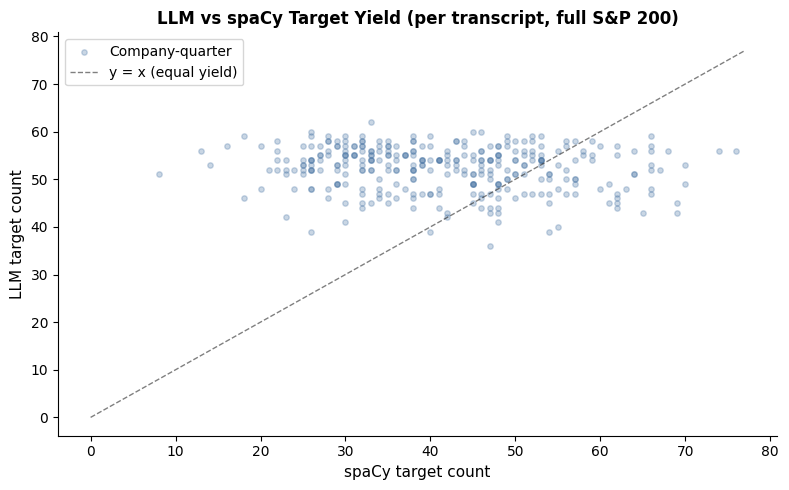


Mean spaCy   : 41.61 targets/transcript
Mean LLM     : 52.31 targets/transcript
Median spaCy : 41
Median LLM   : 53
Ratio        : 1.26×  (LLM extracts 1.3× more targets)


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 — LLM vs spaCy extraction yield comparison (FULL UNIVERSE)
#
# Replaces the demo-scoped comparison cell. Uses spacy_results_full and
# llm_results_full (loaded by the previous cell) so the scatter has all
# 768 (ticker, quarter) entries instead of just the 7 demo pairs.
#
# Output:
#   - matplotlib figure: data/cache/demo/llm_vs_spacy_yield.png
#   - Mean spaCy / LLM targets per call + ratio
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import pandas as pd

if "spacy_results_full" not in globals() or "llm_results_full" not in globals():
    raise RuntimeError(
        "spacy_results_full / llm_results_full not in scope. "
        "Run the full-universe loader cell first."
    )

# Build per-transcript comparison
spacy_idx = {(r['ticker'], r['quarter']): len(r['targets']) for r in spacy_results_full}
llm_idx   = {(r['ticker'], r['quarter']): len(r.get('targets', [])) for r in llm_results_full}

common_keys = set(spacy_idx) & set(llm_idx)
comp_rows = [{'ticker':  k[0],
              'quarter': k[1],
              'spacy_n': spacy_idx[k],
              'llm_n':   llm_idx[k]} for k in common_keys]
comp_df = pd.DataFrame(comp_rows)

print(f"Comparison rows: {len(comp_df):,} (ticker, quarter) pairs")

if not comp_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(comp_df['spacy_n'], comp_df['llm_n'],
               alpha=0.3, s=15, color='#4e79a7', label='Company-quarter')
    max_val = max(comp_df[['spacy_n', 'llm_n']].max()) + 1
    ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5,
            label='y = x (equal yield)')
    ax.set_xlabel('spaCy target count', fontsize=11)
    ax.set_ylabel('LLM target count', fontsize=11)
    ax.set_title('LLM vs spaCy Target Yield (per transcript, full S&P 200)',
                 fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(str(CACHE_DIR / 'llm_vs_spacy_yield.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    avg_spacy = comp_df['spacy_n'].mean()
    avg_llm   = comp_df['llm_n'].mean()
    ratio     = avg_llm / avg_spacy if avg_spacy > 0 else float('nan')
    median_spacy = comp_df['spacy_n'].median()
    median_llm   = comp_df['llm_n'].median()

    print(f"\nMean spaCy   : {avg_spacy:.2f} targets/transcript")
    print(f"Mean LLM     : {avg_llm:.2f} targets/transcript")
    print(f"Median spaCy : {median_spacy:.0f}")
    print(f"Median LLM   : {median_llm:.0f}")
    print(f"Ratio        : {ratio:.2f}×  (LLM extracts {ratio:.1f}× more targets)")

---
## Section 4 — Pre-compute Portfolio Rankings

For each quarter, rank companies by their LLM-derived MT (risk) score so the
**Portfolio Screen tab** in the Gradio demo can instantly display the top-20
high-risk companies without any computation at demo time.

Loaded NB02 spaCy MT: 9,550 rows
  parquet sample cid : np.int64(100231) -> normalized '100231'

Portfolio screen cache saved to: /content/drive/MyDrive/EarningsLens/data/cache/demo/portfolio_screen.json
  2 quarters covered

=== 2020Q4 — ranked by risk score (n=6) ===


,ticker,risk_score,risk_flag,mt_score_spacy,n_dropped,n_extracted,n_hist
0,META,0.189697,unknown,0.652174,15,46,55
1,GOOGL,0.185648,unknown,0.675000,16,58,54
2,T,0.141509,unknown,0.846154,15,55,53
3,MSFT,0.086538,unknown,0.666667,9,50,52
4,AAPL,0.070000,unknown,0.800000,7,55,50
5,NVDA,0.051020,unknown,0.750000,5,48,49



=== 2023Q4 — ranked by risk score (n=6) ===


,ticker,risk_score,risk_flag,mt_score_spacy,n_dropped,n_extracted,n_hist
0,MSFT,0.181571,unknown,0.636364,13,45,48
1,NVDA,0.166667,unknown,0.920000,19,47,57
2,GOOGL,0.163030,unknown,0.533333,15,53,55
3,META,0.103774,unknown,0.574074,11,59,53
4,AAPL,0.085057,unknown,0.757576,6,52,58
5,T,0.081818,unknown,0.764706,9,56,55



────────────────────────────────────────────────────────────────────────
SANITY CHECK — both fixes
────────────────────────────────────────────────────────────────────────
  n_dropped       has nonzero rows : True  (was always False before the fix)
  mt_score_spacy  has nonzero rows : True  (was always False before the fix)
────────────────────────────────────────────────────────────────────────

Risk matrix shape: (6, 2)


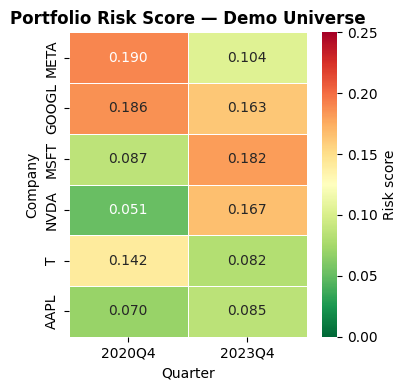

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# NB08 Section 4 — Portfolio rankings (FIXED)
#
# Drop-in replacement for NB08 cell 18.
#
# What this fixes vs the original cell:
#   1. n_dropped was always 0 — old code read cls_res["dropped_targets"], but
#      ClassifierAgent stores drops in cls_res["dropped_financial"] and
#      cls_res["dropped_non_financial"] (and exposes count via cls_res["n_dropped"]).
#   2. mt_score_spacy was always 0 — old code read continuity_results["mt_score"]
#      (which is the LLM continuity score), and labeled it as spaCy in the UI.
#      Now we pull the real spaCy MT from NB02's spacy_mt_scores.parquet,
#      keyed by company_id × quarter — with the .0 suffix normalized so
#      '100231.0' (parquet) matches '100231' (demo_cache).
#
# Outputs:
#   - portfolio_screen.json       : per-quarter ranked tables (Tab 2 input)
#   - portfolio_risk_heatmap.png  : 7-pair risk visualization (unchanged)
#
# Required upstream variables (from earlier NB08 cells):
#   CACHE_DIR, PROCESSED_DIR, DEMO_PAIRS, DEMO_QUARTERS, DEMO_COMPANIES,
#   demo_cache, ticker_to_companyid (built in Section 2)
# ─────────────────────────────────────────────────────────────────────────────

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List


# ── 0a) Tiny helper: strip trailing '.0' from float-cast company_ids ──────
def _norm_cid(x) -> str:
    """Normalize a company_id to a clean string with no '.0' suffix."""
    if x is None:
        return ""
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s


# ── 0b) Load NB02's spaCy MT scores (full corpus) ─────────────────────────
SPACY_MT_PATH = PROCESSED_DIR / "spacy_mt_scores.parquet"

if SPACY_MT_PATH.exists():
    spacy_mt_df = pd.read_parquet(SPACY_MT_PATH)
    spacy_mt_df["_cid_clean"] = spacy_mt_df["company_id"].apply(_norm_cid)
    spacy_mt_df["_q_clean"]   = spacy_mt_df["quarter"].astype(str)
    print(f"Loaded NB02 spaCy MT: {len(spacy_mt_df):,} rows")
    print(f"  parquet sample cid : {spacy_mt_df['company_id'].iloc[0]!r} -> "
          f"normalized {spacy_mt_df['_cid_clean'].iloc[0]!r}")
else:
    spacy_mt_df = pd.DataFrame(columns=["company_id", "quarter", "mt_score",
                                        "_cid_clean", "_q_clean"])
    print(f"[WARN] {SPACY_MT_PATH} not found — spaCy MT column will be 0")

# Build (cid_clean, quarter) -> spacy mt_score lookup
spacy_mt_lookup: Dict[tuple, float] = {
    (r["_cid_clean"], r["_q_clean"]): float(r["mt_score"])
    for _, r in spacy_mt_df.iterrows()
}

# Reverse map: ticker -> companyid (built earlier in NB08 §2)
# Defensive fallback if the variable name differs across runs.
try:
    _ticker_to_cid = ticker_to_companyid  # noqa: F821
except NameError:
    _ticker_to_cid = {}
    for k, v in demo_cache.items():
        if isinstance(v, dict) and "ticker" in v and "company_id" in v:
            _ticker_to_cid[v["ticker"]] = _norm_cid(v["company_id"])
    print(f"[INFO] rebuilt ticker_to_companyid from demo_cache: {_ticker_to_cid}")


# ── 1) Build portfolio rankings per quarter ────────────────────────────────
PORTFOLIO_CACHE_PATH = CACHE_DIR / "portfolio_screen.json"

portfolio_screen: Dict[str, List] = {}

for quarter in DEMO_QUARTERS:
    quarter_data = []
    for company in DEMO_COMPANIES:
        if (company, quarter) not in set(DEMO_PAIRS):
            continue

        key      = f"{company}_{quarter}"
        entry    = demo_cache.get(key, {})
        cls_res  = entry.get("classification_results", {}) or {}
        cont_res = entry.get("continuity_results", {}) or {}

        # ── FIX 1: n_dropped — read from classifier directly ──────────────
        # ClassifierAgent populates cls_res["n_dropped"] explicitly.
        # If absent, sum the financial + non_financial drop lists.
        n_dropped = int(
            cls_res.get(
                "n_dropped",
                len(cls_res.get("dropped_financial", []) or [])
                + len(cls_res.get("dropped_non_financial", []) or []),
            )
            or 0
        )

        risk_score = float(cls_res.get("risk_score", 0.0) or 0.0)
        risk_flag  = cls_res.get("risk_flag", "unknown") or "unknown"

        # ── FIX 2: mt_score_spacy — pull from NB02 parquet, normalized cid ─
        company_id = _norm_cid(
            entry.get("company_id", _ticker_to_cid.get(company, ""))
        )
        mt_score_spacy = spacy_mt_lookup.get((company_id, quarter), 0.0)

        # LLM continuity MT (semantic) — what the old field was actually
        # carrying, kept here under its true name for completeness.
        mt_score_llm_continuity = float(cont_res.get("mt_score", 0.0) or 0.0)

        n_extracted = len(entry.get("extracted_targets", []) or [])
        n_hist      = len(entry.get("historical_targets", []) or [])

        quarter_data.append({
            "ticker":                   company,
            "company_id":               company_id,
            "risk_score":               risk_score,
            "risk_flag":                risk_flag,
            "mt_score":                 mt_score_spacy,           # consumed by app.py as "spaCy MT"
            "mt_score_spacy":           mt_score_spacy,           # explicit alias
            "mt_score_llm_continuity":  mt_score_llm_continuity,  # bonus field
            "n_dropped":                n_dropped,
            "n_extracted":              n_extracted,
            "n_hist":                   n_hist,
        })

    quarter_data.sort(key=lambda x: x["risk_score"], reverse=True)
    portfolio_screen[quarter] = quarter_data

with open(PORTFOLIO_CACHE_PATH, "w") as f:
    json.dump(portfolio_screen, f, indent=2)

print(f"\nPortfolio screen cache saved to: {PORTFOLIO_CACHE_PATH}")
print(f"  {len(portfolio_screen)} quarters covered\n")

# Preview every quarter
for q in DEMO_QUARTERS:
    rows = portfolio_screen.get(q, [])
    if not rows:
        continue
    print(f"=== {q} — ranked by risk score (n={len(rows)}) ===")
    df = pd.DataFrame(rows)
    cols = ["ticker", "risk_score", "risk_flag", "mt_score_spacy",
            "n_dropped", "n_extracted", "n_hist"]
    cols = [c for c in cols if c in df.columns]
    display(df[cols])
    print()


# ── 2) Sanity check: did both fixes work? ──────────────────────────────────
print("─" * 72)
print("SANITY CHECK — both fixes")
print("─" * 72)

any_nonzero_dropped = any(
    r["n_dropped"] > 0
    for rows in portfolio_screen.values() for r in rows
)
any_nonzero_spacy = any(
    r["mt_score_spacy"] > 0
    for rows in portfolio_screen.values() for r in rows
)

print(f"  n_dropped       has nonzero rows : {any_nonzero_dropped}  "
      f"(was always False before the fix)")
print(f"  mt_score_spacy  has nonzero rows : {any_nonzero_spacy}  "
      f"(was always False before the fix)")

if not any_nonzero_dropped:
    print("  [WARN] All n_dropped still 0 — check that demo_cache has fresh "
          "classification_results from the latest pipeline run.")
if not any_nonzero_spacy:
    print("  [WARN] All mt_score_spacy still 0 — check that "
          "spacy_mt_scores.parquet exists and (cid, quarter) keys match.")

print("─" * 72)


# ── 3) Risk heatmap (unchanged from original) ──────────────────────────────
risk_matrix = []
for ticker in DEMO_COMPANIES:
    row = []
    for q in DEMO_QUARTERS:
        if (ticker, q) in set(DEMO_PAIRS):
            key   = f"{ticker}_{q}"
            entry = demo_cache.get(key, {})
            score = entry.get("classification_results", {}).get("risk_score", np.nan)
            row.append(float(score) if score is not None else np.nan)
        else:
            row.append(np.nan)
    risk_matrix.append(row)

risk_df = pd.DataFrame(risk_matrix, index=DEMO_COMPANIES, columns=DEMO_QUARTERS)
risk_df["_max"] = risk_df.max(axis=1, skipna=True)
risk_df = risk_df.sort_values("_max", ascending=False).drop(columns=["_max"])

print(f"\nRisk matrix shape: {risk_df.shape}")

if not risk_df.dropna(how="all").empty:
    fig, ax = plt.subplots(
        figsize=(max(4, len(DEMO_QUARTERS) * 1.6),
                 max(4, len(risk_df) * 0.6)),
    )
    sns.heatmap(
        risk_df,
        cmap="RdYlGn_r",
        vmin=0, vmax=max(0.25, risk_df.max().max() * 1.1),
        annot=True, fmt=".3f",
        linewidths=0.6, linecolor="white",
        ax=ax,
        cbar_kws={"label": "Risk score"},
        mask=risk_df.isna(),
    )
    ax.set_title("Portfolio Risk Score — Demo Universe", fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Company")
    plt.tight_layout()
    plt.savefig(CACHE_DIR / "portfolio_risk_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Risk matrix is empty.")

---
## Section 5 — Test Demo Locally

Before the presentation, verify that:
1. All cache files are present and non-empty
2. The Gradio app loads results from the cache correctly
3. The interface renders without errors

The cell that launches Gradio will open a local server at `http://localhost:7860`.

In [14]:
# ── Verify cache files exist and are non-empty ────────────────────────────────

print(f"Cache directory: {CACHE_DIR}\n")
print(f"{'File':<40} {'Size':>10} {'Status'}")
print("-" * 60)

for fname in sorted(os.listdir(CACHE_DIR)):
    fpath = CACHE_DIR / fname
    if fpath.is_file():
        size_kb = fpath.stat().st_size / 1024
        status = "OK" if size_kb > 1 else "⚠ EMPTY"
        print(f"  {fname:<38} {size_kb:>8.1f} KB   {status}")

Cache directory: /content/drive/MyDrive/EarningsLens/data/cache/demo

File                                           Size Status
------------------------------------------------------------
  llm_extraction_cache.json                  64.9 KB   OK
  llm_results.json                          289.2 KB   OK
  llm_vs_spacy_yield.png                     77.5 KB   OK
  pipeline_cache.json                      4742.8 KB   OK
  portfolio_risk_heatmap.png                 51.4 KB   OK
  portfolio_screen.json                       3.7 KB   OK
  spacy_results.json                         42.1 KB   OK


In [15]:
import json, pathlib

CACHE_DIR = pathlib.Path("/content/drive/MyDrive/EarningsLens/data/cache/demo")

# 1. pipeline_cache.json — top-level keys + one sample payload
pc = json.loads((CACHE_DIR / "pipeline_cache.json").read_text())
print("pipeline_cache.json keys:", list(pc.keys()))
sample_key = next(iter(pc))
sample = pc[sample_key]
print(f"\nSample key: {sample_key}")
print("Top-level fields:", list(sample.keys()))
for k, v in sample.items():
    if isinstance(v, list):
        print(f"  {k}: list[{len(v)}]")
    elif isinstance(v, dict):
        print(f"  {k}: dict keys={list(v.keys())}")
    else:
        print(f"  {k}: {type(v).__name__} = {str(v)[:80]}")

# 2. portfolio_screen.json
ps = json.loads((CACHE_DIR / "portfolio_screen.json").read_text())
print("\nportfolio_screen.json keys:", list(ps.keys()))
for q, rows in ps.items():
    print(f"  {q}: {len(rows)} rows, sample={rows[0] if rows else None}")

# 3. per_quarter/ files
pq_dir = CACHE_DIR / "per_quarter"
pq_files = sorted(pq_dir.glob("*.json"))
print(f"\nper_quarter/: {len(pq_files)} files")
for f in pq_files[:3]:
    print(f"  {f.name}")

pipeline_cache.json keys: ['AAPL_2020Q4', 'AAPL_2023Q4', 'T_2023Q4', 'MSFT_2023Q4', 'NVDA_2023Q4', 'META_2023Q4', 'GOOGL_2023Q4', 'T_2020Q4', 'MSFT_2020Q4', 'NVDA_2020Q4', 'META_2020Q4', 'GOOGL_2020Q4']

Sample key: AAPL_2020Q4
Top-level fields: ['ticker', 'quarter', 'company_id', 'extracted_targets', 'spacy_baseline_targets', 'historical_targets', 'continuity_results', 'classification_results', 'report', 'errors']
  ticker: str = AAPL
  quarter: str = 2020Q4
  company_id: str = 24937
  extracted_targets: list[55]
  spacy_baseline_targets: list[27]
  historical_targets: list[50]
  continuity_results: dict keys=['maintained', 'rephrased', 'dropped', 'details', 'historical_lag', 'thresholds']
  classification_results: dict keys=['dropped_financial', 'dropped_non_financial', 'persistent_dropped', 'ephemeral_dropped', 'n_dropped', 'n_total', 'risk_score', 'financial_drop_ratio', 'nonfinancial_drop_ratio', 'persistent_drop_ratio']
  report: dict keys=['summary', 'risk_flag', 'risk_score', '

In [16]:
# Clear cache + reload

from demo.app import _TICKERS, _QUARTERS, _IN_MEMORY_CACHE, _PORTFOLIO_SCREEN_BLOB
print(f"Tickers: {_TICKERS}")
print(f"Quarters: {_QUARTERS}")
print(f"Cache pairs: {len(_IN_MEMORY_CACHE)}")
print(f"Portfolio quarters: {list(_PORTFOLIO_SCREEN_BLOB.keys())}")

Tickers: ['AAPL', 'GOOGL', 'META', 'MSFT', 'NVDA', 'T']
Quarters: ['2020Q4', '2023Q4']
Cache pairs: 12
Portfolio quarters: ['2020Q4', '2023Q4']


In [17]:
# Test the app
!cd /content/drive/MyDrive/EarningsLens && python demo/app.py --share

INFO __main__: Demo cache: 6 tickers, 2 quarters, 12 cached results
INFO httpx: HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
* Running on local URL:  http://0.0.0.0:7860
INFO httpx: HTTP Request: GET http://localhost:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD http://localhost:7860/ "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64 "HTTP/1.1 200 OK"
* Running on public URL: https://198202e13e8c971315.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
INFO httpx: HTTP Reques

In [18]:
# ── Final cache summary ───────────────────────────────────────────────────────
# Print a clean summary of everything that has been pre-computed.

print("=" * 55)
print("  DEMO PRE-COMPUTATION SUMMARY")
print("=" * 55)
print()

summary_files = [
    ("spacy_results.json",     "spaCy extraction + MT scores"),
    ("llm_results.json",       "LLM extraction + MT scores"),
    ("pipeline_cache.json",    "Full pipeline output (all agents)"),
    ("portfolio_screen.json",  "Portfolio rankings by quarter"),
]

total_size = 0
for fname, desc in summary_files:
    fpath = CACHE_DIR / fname
    if fpath.exists():
        sz = fpath.stat().st_size / 1024
        total_size += sz
        print(f"  {fname:<35} {sz:>8.1f} KB  {desc}")
    else:
        print(f"  {fname:<35}  NOT FOUND  {desc}")

print(f"\n  Total cache size: {total_size:.1f} KB  ({total_size/1024:.2f} MB)")
print()

# Show coverage stats
if PIPELINE_CACHE_PATH.exists():
    pc = json.loads(PIPELINE_CACHE_PATH.read_text())
    companies_covered = {k.split("_")[0] for k in pc.keys()}
    quarters_covered  = {"_".join(k.split("_")[1:]) for k in pc.keys()}
    print(f"  Pipeline cache coverage:")
    print(f"    Company-quarters: {len(pc):,}")
    print(f"    Companies:        {len(companies_covered)} / {len(DEMO_COMPANIES)}")
    print(f"    Quarters:         {len(quarters_covered)} / {len(DEMO_QUARTERS)}")

print()
print("=" * 55)
print("  Pre-computation complete. Ready for demo.")
print("=" * 55)

  DEMO PRE-COMPUTATION SUMMARY

  spacy_results.json                      42.1 KB  spaCy extraction + MT scores
  llm_results.json                       289.2 KB  LLM extraction + MT scores
  pipeline_cache.json                   4742.8 KB  Full pipeline output (all agents)
  portfolio_screen.json                    3.7 KB  Portfolio rankings by quarter

  Total cache size: 5077.8 KB  (4.96 MB)

  Pipeline cache coverage:
    Company-quarters: 12
    Companies:        6 / 6
    Quarters:         2 / 2

  Pre-computation complete. Ready for demo.
